In [19]:
from __future__ import annotations

import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import scipy.stats as st
import statsmodels.api as sm
import shap
import lightgbm as lgb
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
import matplotlib as mpl
import re 
from shapely.geometry import Point, shape, Polygon


from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold
from sklearn.neighbors import NearestNeighbors


try:
    from libpysal.weights import Queen
    from esda.moran import Moran
    HAS_MORAN = True
except ImportError:
    HAS_MORAN = False

In [2]:
BASE_DIR = Path(".")
PATHS = {
    "locus": BASE_DIR / "LOCUS_IL_Idling.shp",
    "warehouse": BASE_DIR / "../WarehouseMidwest.shp",
    "truck_stops": BASE_DIR / "Truck_Stop_Parking.shp",
    "terminals": BASE_DIR / "../LOCUS/Intermodal_Freight_Facilities_Pipeline_Terminals.shp",
    "freight_rail": BASE_DIR / "../LOCUS/Intermodal_Freight_Facilities_Rail_TOFC_COFC.shp",
    "airports": BASE_DIR / "IL_Airports.shp",
    "gas_station": BASE_DIR / "Alternative_Fueling_Stations.shp",
    "primary_roads": BASE_DIR / "../tl_2016_us_primaryroads.shp",
    "allroads": BASE_DIR / "../tl_2019_17_prisecroads.shp",
}

OUTPUT_DIR = BASE_DIR / "optimized_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

TARGET_CRS = "EPSG:4326"
METRIC_CRS = "EPSG:3857"
K_NEIGHBORS = 8
HPMS_CHUNK_SIZE = 1500  # lower if RAM is still tight
RANDOM_STATE = 42

In [3]:
def force_gc(*objs):
    for obj in objs:
        try:
            del obj
        except Exception:
            pass
    gc.collect()


def shrink_numeric_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast numeric columns to reduce RAM."""
    out = df.copy()
    for col in out.columns:
        if pd.api.types.is_integer_dtype(out[col]):
            out[col] = pd.to_numeric(out[col], downcast="integer")
        elif pd.api.types.is_float_dtype(out[col]):
            out[col] = pd.to_numeric(out[col], downcast="float")
    return out


def read_vector(path, columns=None, mask=None, target_crs=TARGET_CRS) -> gpd.GeoDataFrame:
    """
    Read only required columns, optionally with a mask, and normalize CRS once.
    geopandas.read_file(..., mask=...) pushes spatial filtering into GDAL/OGR where possible.
    """
    gdf = gpd.read_file(path, columns=columns, mask=mask)
    if gdf.crs is None:
        raise ValueError(f"{path} has no CRS; set it explicitly before continuing.")
    if str(gdf.crs) != target_crs:
        gdf = gdf.to_crs(target_crs)
    return gdf


def read_and_clip_points(path, locus_mask, columns=None, target_crs=TARGET_CRS) -> gpd.GeoDataFrame:
    """Read with mask to avoid loading the full source, then keep only requested columns + geometry."""
    cols = list(columns or [])
    gdf = read_vector(path, columns=cols, mask=locus_mask, target_crs=target_crs)
    keep = [c for c in cols if c in gdf.columns] + ["geometry"]
    return gdf[keep].copy()


def prep_grid(locus: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    keep_cols = [c for c in ["MDT_avg_da", "HDT_avg_da", "Total_avg_", "geometry"] if c in locus.columns]
    grid = locus[keep_cols].copy().reset_index(drop=True)
    grid["grid_id"] = np.arange(len(grid), dtype=np.int32)
    return grid


def build_knn_index(grid_gdf: gpd.GeoDataFrame, k=K_NEIGHBORS) -> np.ndarray:
    g = grid_gdf[["grid_id", "geometry"]].to_crs(METRIC_CRS)
    cent = g.geometry.centroid
    coords = np.column_stack([cent.x.to_numpy(), cent.y.to_numpy()]).astype("float32")
    nn = NearestNeighbors(n_neighbors=k + 1, algorithm="ball_tree")
    nn.fit(coords)
    _, idx = nn.kneighbors(coords)
    nbr_idx = idx[:, 1:].astype(np.int32)  # drop self
    force_gc(g, cent, coords, idx)
    return nbr_idx


def add_knn_sum_inplace(df: gpd.GeoDataFrame, cols, nbr_idx, suffix=f"_knn{K_NEIGHBORS}") -> None:
    for c in cols:
        vals = pd.to_numeric(df[c], errors="coerce").fillna(0).to_numpy(dtype="float32", copy=False)
        df[f"{c}{suffix}"] = vals[nbr_idx].sum(axis=1, dtype="float32")


def count_points_within_inplace(polygons: gpd.GeoDataFrame, points: gpd.GeoDataFrame, out_col: str) -> None:
    if points.empty:
        polygons[out_col] = np.zeros(len(polygons), dtype=np.int32)
        return
    left = points[["geometry"]].copy()
    right = polygons[["grid_id", "geometry"]].copy()
    joined = gpd.sjoin(left, right, how="left", predicate="within")
    counts = joined.groupby("grid_id").size().astype("int32")
    polygons[out_col] = polygons["grid_id"].map(counts).fillna(0).astype("int32")
    force_gc(left, right, joined, counts)


def sum_points_within_inplace(polygons: gpd.GeoDataFrame, points: gpd.GeoDataFrame, value_col: str, out_col: str) -> None:
    if points.empty:
        polygons[out_col] = np.zeros(len(polygons), dtype="float32")
        return
    left = points[[value_col, "geometry"]].copy()
    left[value_col] = pd.to_numeric(left[value_col], errors="coerce").fillna(0).astype("float32")
    right = polygons[["grid_id", "geometry"]].copy()
    joined = gpd.sjoin(left, right, how="left", predicate="within")
    sums = joined.groupby("grid_id")[value_col].sum().astype("float32")
    polygons[out_col] = polygons["grid_id"].map(sums).fillna(0).astype("float32")
    force_gc(left, right, joined, sums)


def safe_log1p_frame(df: pd.DataFrame, cols) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        out[c] = np.log1p(pd.to_numeric(out[c], errors="coerce").fillna(0).astype("float32"))
    return out


In [4]:
print("Reading locus/grid...")
locus = read_vector(PATHS["locus"], target_crs=TARGET_CRS)

# use locus extent as a read mask for the other layers
locus_mask = locus[["geometry"]]

print("Reading ancillary layers with masked reads...")
wh_IL = read_and_clip_points(PATHS["warehouse"], locus_mask, columns=["RBA", "Number O_7"])
truck_stops_IL = read_and_clip_points(PATHS["truck_stops"], locus_mask)
terminals_IL = read_and_clip_points(PATHS["terminals"], locus_mask)
freight_rail_IL = read_and_clip_points(PATHS["freight_rail"], locus_mask)
airports_IL = read_and_clip_points(PATHS["airports"], locus_mask)
gas_station_IL = read_and_clip_points(PATHS["gas_station"], locus_mask)
primary_roads = read_vector(PATHS["primary_roads"],mask=locus_mask,target_crs=TARGET_CRS)
allroads = read_vector(PATHS["allroads"],mask=locus_mask,target_crs=TARGET_CRS)

Reading locus/grid...
Reading ancillary layers with masked reads...


In [5]:
grid = prep_grid(locus)

count_points_within_inplace(grid, wh_IL, "wh_count")
count_points_within_inplace(grid, truck_stops_IL, "truck_stop_count")
count_points_within_inplace(grid, terminals_IL, "terminal_count")
count_points_within_inplace(grid, freight_rail_IL, "freight_rail_count")

# Combined freight establishment count
grid["freight_est_count"] = (
    grid["truck_stop_count"]
    + grid["terminal_count"]
    + grid["freight_rail_count"]
).astype("int32")

# Optional KNN-smoothed counts
nbr_idx = build_knn_index(grid, k=K_NEIGHBORS)

add_knn_sum_inplace(
    grid,
    ["wh_count", "truck_stop_count", "terminal_count", "freight_rail_count", "freight_est_count"],
    nbr_idx
)

# # Choose whether to plot raw counts or smoothed counts
# WH_COL = "wh_count_knn8"
# FREIGHT_COL = "freight_est_count_knn8"

In [6]:
cmap_roads_I = allroads.loc[allroads["RTTYP"] == "I"].copy()
cmap_roads_S = allroads.loc[allroads["RTTYP"] == "S"].copy()
cmap_roads_M = allroads.loc[allroads["RTTYP"] == "M"].copy()
cmap_roads_O = allroads.loc[allroads["RTTYP"] == "O"].copy()

# Use locus/grid dissolved boundary as CMAP-ish plotting boundary
study_boundary = grid.dissolve()

In [7]:
def set_cmap_extent(ax, gdf):
    xmin, ymin, xmax, ymax = gdf.total_bounds
    dx = (xmax - xmin) * 0.04
    dy = (ymax - ymin) * 0.04
    ax.set_xlim(xmin - dx, xmax + dx)
    ax.set_ylim(ymin - dy, ymax + dy)


def add_common_base(ax):
    grid.boundary.plot(ax=ax, color="lightgrey", linewidth=0.08, alpha=0.35)
    study_boundary.boundary.plot(ax=ax, color="black", linewidth=1.2)
    ax.set_axis_off()
    set_cmap_extent(ax, study_boundary)


def make_count_bins(values):
    vmax = np.nanmax(values)
    if vmax <= 5:
        bins = [0, 1, 2, 3, 4, 5]
    elif vmax <= 20:
        bins = [0, 1, 3, 5, 10, 20]
    else:
        bins = [0, 1, 5, 10, 20, 50, vmax]
    return np.unique(bins)



In [8]:
def add_common_base_no_grid(ax):
    # plot only the outer boundary, not individual LOCUS cells
    locus.dissolve().boundary.plot(
        ax=ax,
        color="black",
        linewidth=1.0,
        zorder=20
    )

    ax.set_axis_off()
    ax.set_aspect("equal")

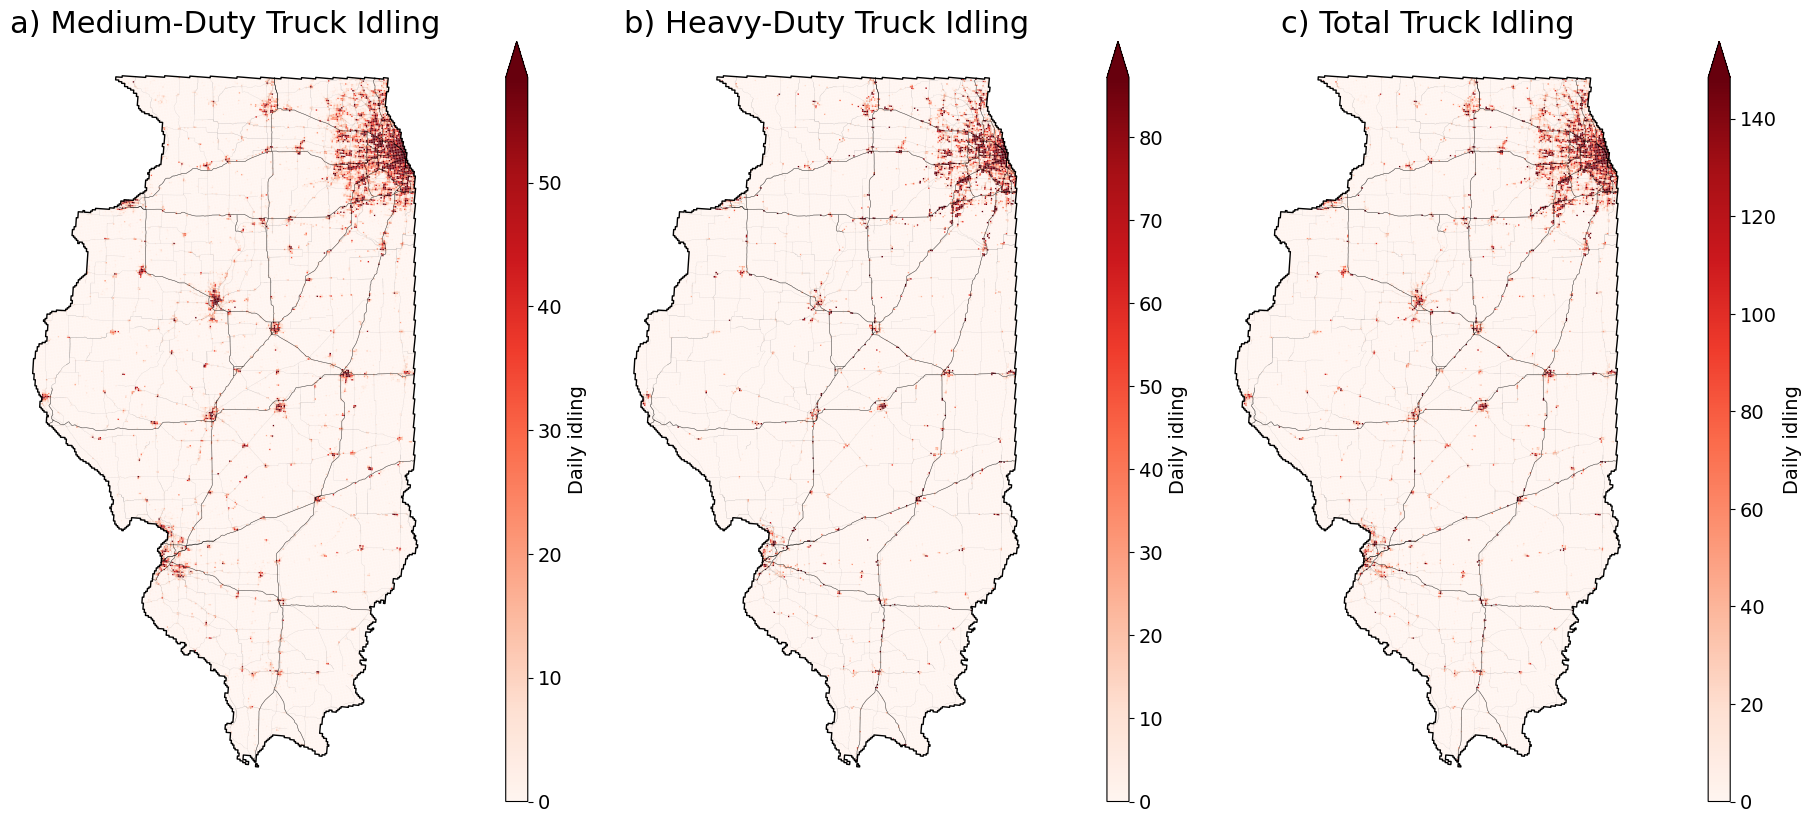

In [12]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 8),
    constrained_layout=True
)

ax0, ax1, ax2 = axes

def plot_locus_idling(ax, col, title, cbar_label):
    add_common_base_no_grid(ax)

    vals = locus[col].replace([np.inf, -np.inf], np.nan).dropna()

    vmin = 0
    vmax = vals.quantile(0.99)

    locus.plot(
        ax=ax,
        column=col,
        cmap="Reds",
        edgecolor="none",
        linewidth=0,
        legend=False,
        vmin=vmin,
        vmax=vmax
    )

    cmap_roads_I.plot(ax=ax, color="black", linewidth=0.35, alpha=0.45)
    cmap_roads_S.plot(ax=ax, color="grey", linewidth=0.20, alpha=0.30)

    sm = mpl.cm.ScalarMappable(
        norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax),
        cmap="Reds"
    )
    sm.set_array([])

    from mpl_toolkits.axes_grid1 import make_axes_locatable

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.05)

    cbar = plt.colorbar(sm, cax=cax, extend="max")

    cbar.set_label(cbar_label, fontsize=14)
    cbar.ax.tick_params(labelsize=14)

    ax.set_title(title, fontsize=22)


plot_locus_idling(
    ax0,
    "MDT_avg_da",
    "a) Medium-Duty Truck Idling",
    "Daily idling"
)

plot_locus_idling(
    ax1,
    "HDT_avg_da",
    "b) Heavy-Duty Truck Idling",
    "Daily idling"
)

plot_locus_idling(
    ax2,
    "Total_avg_",
    "c) Total Truck Idling",
    "Daily idling"
)

# out_png = OUTPUT_DIR / "IL_idling_only_3panel.png"
# out_tif = OUTPUT_DIR / "IL_idling_only_3panel.pdf"

# plt.savefig(out_png, dpi=300, bbox_inches="tight")
# plt.savefig(out_tif, dpi=300, bbox_inches="tight")
plt.show()

In [13]:
# ============================================================
# CLIP EVERYTHING TO CMAP COUNTIES + PLOT ZOOMED CHICAGO REGION
# ============================================================

from matplotlib.lines import Line2D

# ------------------------------------------------------------
# 1. Read CMAP counties../cmap if not already loaded
# ------------------------------------------------------------

cmap_cty = gpd.read_file("../cmap_cty.shp").to_crs(TARGET_CRS)

# Dissolved CMAP boundary for clipping / extent
cmap_boundary = cmap_cty.dissolve()

# ------------------------------------------------------------
# 2. Clip all plotting layers to CMAP only
# ------------------------------------------------------------

grid_cmap = gpd.clip(grid, cmap_cty)
allroads_cmap = gpd.clip(allroads, cmap_cty)
primary_roads_cmap = gpd.clip(primary_roads, cmap_cty)

cmap_roads_I = allroads_cmap.loc[allroads_cmap["RTTYP"] == "I"].copy()
cmap_roads_S = allroads_cmap.loc[allroads_cmap["RTTYP"] == "S"].copy()
cmap_roads_M = allroads_cmap.loc[allroads_cmap["RTTYP"] == "M"].copy()
cmap_roads_O = allroads_cmap.loc[allroads_cmap["RTTYP"] == "O"].copy()

wh_cmap = gpd.clip(wh_IL, cmap_cty)
truck_stops_cmap = gpd.clip(truck_stops_IL, cmap_cty)
terminals_cmap = gpd.clip(terminals_IL, cmap_cty)
freight_rail_cmap = gpd.clip(freight_rail_IL, cmap_cty)
gas_station_cmap = gpd.clip(gas_station_IL, cmap_cty)

In [14]:
# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------

def set_chicago_extent(ax, boundary, pad=0.06):
    xmin, ymin, xmax, ymax = boundary.total_bounds
    dx = (xmax - xmin) * pad
    dy = (ymax - ymin) * pad
    ax.set_xlim(xmin - dx, xmax + dx)
    ax.set_ylim(ymin - dy, ymax + dy)


def add_common_base(ax):
    # light fill makes CMAP counties stand apart from background
    cmap_cty.plot(
        ax=ax,
        facecolor="#f7f7f7",
        edgecolor="black",
        linewidth=0.7,
        alpha=1.0,
        zorder=0
    )

    # county boundary emphasis
    cmap_cty.boundary.plot(
        ax=ax,
        color="black",
        linewidth=0.8,
        alpha=0.75,
        zorder=5
    )

    # outer CMAP dissolved boundary
    cmap_boundary.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1.5,
        zorder=6
    )

    ax.set_axis_off()
    set_chicago_extent(ax, cmap_boundary)


def make_count_bins(values):
    vmax = np.nanmax(values)

    if vmax <= 5:
        bins = [0, 1, 2, 3, 4, 5]
    elif vmax <= 20:
        bins = [0, 1, 3, 5, 10, 20]
    elif vmax <= 50:
        bins = [0, 1, 5, 10, 20, 50]
    else:
        bins = [0, 1, 5, 10, 20, 50, vmax]

    return np.unique(bins)



In [15]:
def add_interstate_labels(
    ax,
    roads,
    interstate_numbers,
    fontsize=9,
    label_every=10,
    min_segment_length=0.03,):
    label_roads = roads.dropna(subset=["FULLNAME"]).copy()

    label_roads["INTERSTATE"] = (
        label_roads["FULLNAME"]
        .astype(str)
        .str.extract(
            r"(?:I|INTERSTATE)[\s\-]*(\d+)",
            flags=re.IGNORECASE
        )[0]
    )

    interstate_numbers = [str(number) for number in interstate_numbers]

    label_roads = label_roads[
        label_roads["INTERSTATE"].isin(interstate_numbers)
    ].copy()

    for interstate_number, group in label_roads.groupby("INTERSTATE"):

        valid_lines = []

        for geom in group.geometry:
            if geom is None or geom.is_empty:
                continue

            if geom.geom_type == "LineString":
                if len(geom.coords) >= 2 and geom.length >= min_segment_length:
                    valid_lines.append(geom)

            elif geom.geom_type == "MultiLineString":
                for part in geom.geoms:
                    if (
                        not part.is_empty
                        and len(part.coords) >= 2
                        and part.length >= min_segment_length
                    ):
                        valid_lines.append(part)

        # Sort roughly along the road
        valid_lines = sorted(
            valid_lines,
            key=lambda line: (line.centroid.x, line.centroid.y)
        )

        # Label every other qualifying segment
        for line in valid_lines[::label_every]:

            point = line.interpolate(0.5, normalized=True)

            ax.text(
                point.x,
                point.y,
                f"I-{interstate_number}",
                fontsize=fontsize,
                fontweight="bold",
                ha="center",
                va="center",
                color="dimgray",
                zorder=50,
                path_effects=[
                    pe.Stroke(linewidth=2, foreground="white"),
                    pe.Normal(),
                ],
            )
            
def add_county_labels(
    ax,
    counties,
    name_column="NAME",
    fontsize=16,
    color="lightgray",
):
    for _, row in counties.iterrows():
        geom = row.geometry

        if geom is None or geom.is_empty:
            continue

        point = geom.representative_point()

        ax.text(
            point.x,
            point.y+0.03,
            row[name_column],
            fontsize=fontsize,
            color=color,
            fontweight="normal",
            ha="center",
            va="center",
            alpha=0.85,
            zorder=40,
            path_effects=[
                pe.Stroke(linewidth=2, foreground="white"),
                pe.Normal(),
            ],
        )

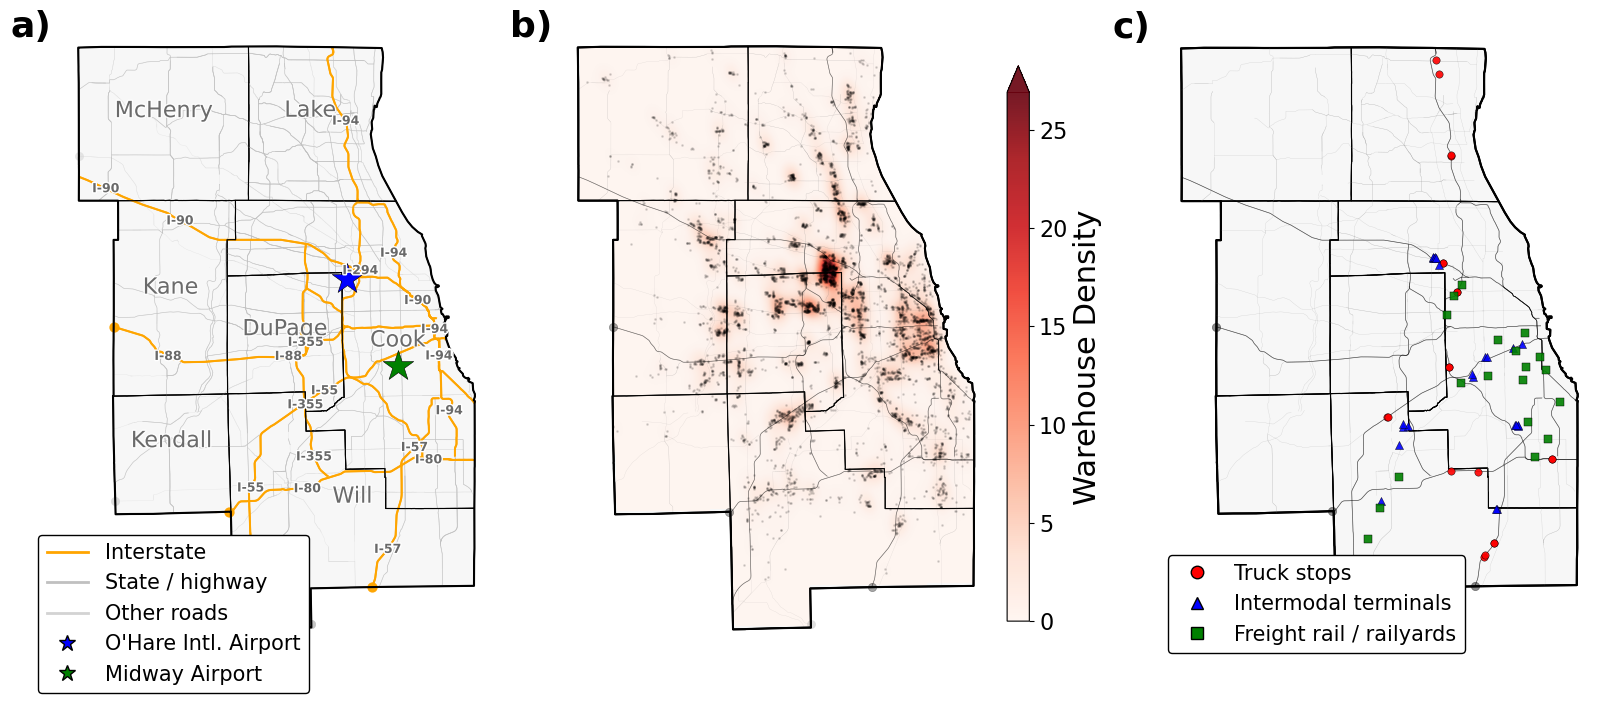

In [20]:
major_interstates = [55, 57, 80, 88, 90, 94, 294, 355]

fig, axes = plt.subplots(1, 3, figsize=(16, 8), constrained_layout=True)
ax0, ax1, ax2 = axes

# ============================================================
# PANEL A: ROAD NETWORK AND AIRPORTS
# ============================================================

add_common_base(ax0)
allroads_cmap.plot(ax=ax0, color="lightgrey", linewidth=0.25, alpha=0.55, zorder=1)
cmap_roads_S.plot(ax=ax0, color="silver", linewidth=0.45, alpha=0.85, zorder=2)
cmap_roads_I.plot(ax=ax0, color="orange", linewidth=1.4, alpha=0.95, zorder=3)
add_county_labels(ax0, cmap_cty, fontsize=16, color="#555555")
add_interstate_labels(ax0, cmap_roads_I, interstate_numbers=major_interstates, fontsize=9, label_every=3, min_segment_length=0.03)
ax0.scatter(-87.904724, 41.978611, marker="*", s=530, color="blue", edgecolor="black", linewidth=0.4, zorder=10)
ax0.scatter(-87.7522, 41.7868, marker="*", s=530, color="green", edgecolor="black", linewidth=0.4, zorder=10)
#ax0.set_title("a)", fontsize=26)
ax0.text(-0.10,  0.95, "a)", transform=ax0.transAxes, fontsize=26, fontweight="bold", ha="left", va="bottom")

road_legend = [
    Line2D([0], [0], color="orange", lw=2, label="Interstate"),
    Line2D([0], [0], color="silver", lw=2, label="State / highway"),
    Line2D([0], [0], color="lightgrey", lw=2, label="Other roads"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="blue", markeredgecolor="black", markersize=12, label="O'Hare Intl. Airport"),
    Line2D([0], [0], marker="*", color="w", markerfacecolor="green", markeredgecolor="black", markersize=12, label="Midway Airport"),
]

leg = ax0.legend(handles=road_legend, loc="lower left",bbox_to_anchor=(-0.06, -0.06), fontsize=15, frameon=True, facecolor="white", edgecolor="black", framealpha=1.0)
leg.set_zorder(1000)

# ============================================================
# PANEL B: WAREHOUSE DENSITY
# ============================================================

add_common_base(ax1)

x = wh_cmap.geometry.x.values
y = wh_cmap.geometry.y.values
kde = gaussian_kde(np.vstack([x, y]), bw_method=0.08)

xmin, ymin, xmax, ymax = cmap_boundary.total_bounds
nx, ny = 300, 300
xi = np.linspace(xmin, xmax, nx)
yi = np.linspace(ymin, ymax, ny)
xx, yy = np.meshgrid(xi, yi)

positions = np.vstack([xx.ravel(), yy.ravel()])
zz = kde(positions).reshape(xx.shape)
cmap_poly = cmap_boundary.geometry.iloc[0]
inside = np.array([cmap_poly.contains(Point(px, py)) or cmap_poly.touches(Point(px, py)) for px, py in zip(xx.ravel(), yy.ravel())]).reshape(xx.shape)
zz_masked = np.where(inside, zz, np.nan)

im = ax1.imshow(zz_masked, extent=[xmin, xmax, ymin, ymax], origin="lower", cmap="Reds", alpha=0.90, interpolation="bilinear", zorder=2)
cmap_roads_I.plot(ax=ax1, color="black", linewidth=0.45, alpha=0.35, zorder=5)
cmap_roads_S.plot(ax=ax1, color="grey", linewidth=0.20, alpha=0.25, zorder=5)
cmap_cty.boundary.plot(ax=ax1, color="black", linewidth=0.5, alpha=0.55, zorder=6)
cmap_boundary.boundary.plot(ax=ax1, color="black", linewidth=1.3, zorder=7)
wh_cmap.plot(ax=ax1, color="black", markersize=1, alpha=0.12, zorder=8)

cbar = plt.colorbar(im, ax=ax1, fraction=0.05, pad=0.02, extend="max", aspect=25)
cbar.set_label("Warehouse Density", fontsize=22)
cbar.ax.tick_params(labelsize=16)
#ax1.set_title("b)", fontsize=26)
ax1.text(-0.10, .95, "b)", transform=ax1.transAxes, fontsize=26, fontweight="bold", ha="left", va="bottom")

# ============================================================
# PANEL C: TRUCK-SUPPORTING INFRASTRUCTURE
# ============================================================

add_common_base(ax2)
cmap_cty.boundary.plot(ax=ax2, color="black", linewidth=0.6, alpha=0.65, zorder=5)
cmap_boundary.boundary.plot(ax=ax2, color="black", linewidth=1.5, zorder=6)
cmap_roads_I.plot(ax=ax2, color="black", linewidth=0.45, alpha=0.45, zorder=7)
cmap_roads_S.plot(ax=ax2, color="grey", linewidth=0.25, alpha=0.3, zorder=7)
truck_stops_cmap.plot(ax=ax2, color="red", marker="o", markersize=28, edgecolor="black", linewidth=0.35, alpha=0.90, zorder=10)
terminals_cmap.plot(ax=ax2, color="blue", marker="^", markersize=34, edgecolor="black", linewidth=0.35, alpha=0.90, zorder=10)
freight_rail_cmap.plot(ax=ax2, color="green", marker="s", markersize=28, edgecolor="black", linewidth=0.35, alpha=0.90, zorder=10)

infra_legend = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="red", markeredgecolor="black", markersize=9, label="Truck stops"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="blue", markeredgecolor="black", markersize=9, label="Intermodal terminals"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="green", markeredgecolor="black", markersize=9, label="Freight rail / railyards"),
]

leg = ax2.legend(handles=infra_legend, loc="lower left", fontsize=15, frameon=True, facecolor="white", edgecolor="black", framealpha=1.0)
leg.set_zorder(1000)
#ax2.set_title("c)", fontsize=26)
ax2.text(-0.10, 0.95, "c)", transform=ax2.transAxes, fontsize=26, fontweight="bold", ha="left", va="bottom")

# ============================================================
# SAVE
# ============================================================

# out_png = OUTPUT_DIR / "CMAP_truck_network_warehouse_infrastructure.png"
# out_tif = OUTPUT_DIR / "CMAP_truck_network_warehouse_infrastructure.tiff"
# plt.savefig(out_png, dpi=300, bbox_inches="tight")
# plt.savefig(out_tif, dpi=300, bbox_inches="tight")
plt.show()